
# Disease Symptom Prediction - Model Explainability Using SHAP

## Project

AI Disease Prediction System

## Objective

The objective of this notebook is to interpret the trained machine
learning model using SHAP (SHapley Additive exPlanations).

The analysis focuses on understanding how the trained model uses
symptom-related features when making disease predictions.

The workflow includes:

- Loading the trained machine learning pipeline
- Loading the processed dataset
- Recreating the train-test split
- Extracting transformed feature names
- Preparing data for SHAP analysis
- Calculating SHAP values for selected predictions
- Analyzing global feature importance
- Visualizing SHAP feature contributions
- Analyzing individual predictions
- Saving SHAP results and visualizations

### Important Interpretation Note

SHAP values describe the contribution of model features to a prediction.
They represent learned model behavior and should not be interpreted as
medical causation or clinical evidence.

---

**Author:** Shahbaj Tanvir Shawon

**Course:** CSE Project

**Notebook:** 04_SHAP.ipynb

# 1. Import Required Libraries

This notebook focuses on SHAP-based model explainability and
real-world prediction logic for the AI Disease Prediction System.

The required libraries are used for:

- Data manipulation
- Numerical computation
- Visualization
- Machine learning utilities
- SHAP explainability
- Model loading

The trained machine learning pipeline from Week 3 will be reused.
No model retraining is performed in this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from joblib import load

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("SHAP EXPLAINABILITY ENVIRONMENT")
print("=" * 60)

print(f"SHAP version: {shap.__version__}")

print("\n✓ Required libraries imported successfully.")

SHAP EXPLAINABILITY ENVIRONMENT
SHAP version: 0.52.0

✓ Required libraries imported successfully.


# 2. Project Configuration

Project paths are centralized in this section.

The processed dataset generated during the data-cleaning stage and
the final trained pipeline generated during Week 3 are reused.

SHAP outputs will be stored separately inside the processed data
directory.

In [2]:
PROJECT_ROOT = Path("../")

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT / "models"
)

MODEL_RESULTS_DIR = (
    PROCESSED_DATA_DIR / "model_results"
)

SHAP_OUTPUT_DIR = (
    PROCESSED_DATA_DIR / "shap_outputs"
)

DATA_FILE = (
    PROCESSED_DATA_DIR / "disease_clean.csv"
)

MODEL_FILE = (
    MODEL_DIR / "disease_prediction_model.pkl"
)

TARGET_COLUMN = "Disease"

SHAP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print(f"Project root       : {PROJECT_ROOT.resolve()}")
print(f"Processed dataset  : {DATA_FILE.resolve()}")
print(f"Model file         : {MODEL_FILE.resolve()}")
print(f"SHAP output folder : {SHAP_OUTPUT_DIR.resolve()}")
print(f"Target column      : {TARGET_COLUMN}")

print("\n✓ Project configuration completed successfully.")

PROJECT CONFIGURATION
Project root       : E:\AI_Disease_Prediction
Processed dataset  : E:\AI_Disease_Prediction\data\processed\disease_clean.csv
Model file         : E:\AI_Disease_Prediction\models\disease_prediction_model.pkl
SHAP output folder : E:\AI_Disease_Prediction\data\processed\shap_outputs
Target column      : Disease

✓ Project configuration completed successfully.


# 3. Load Processed Dataset

The processed disease-symptom dataset created during the data-cleaning
stage is loaded for SHAP analysis.

The dataset is not modified in this notebook.

The target variable is `Disease`, while the remaining columns are used
as model input features.

In [3]:
df = pd.read_csv(DATA_FILE)

print("=" * 60)
print("PROCESSED DATASET")
print("=" * 60)

print(f"Dataset shape : {df.shape}")
print(f"Rows          : {df.shape[0]}")
print(f"Columns       : {df.shape[1]}")
print(f"Disease classes: {df[TARGET_COLUMN].nunique()}")

print("\nFirst 5 rows:")
display(df.head())

print("\n✓ Processed dataset loaded successfully.")

PROCESSED DATASET
Dataset shape : (4920, 19)
Rows          : 4920
Columns       : 19
Disease classes: 41

First 5 rows:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17,Symptom_Count
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3



✓ Processed dataset loaded successfully.


# 4. Load Final Trained Pipeline

The final machine learning pipeline generated during Week 3 is loaded
using Joblib.

The complete pipeline is reused so that the original preprocessing
configuration and trained classifier remain consistent with the model
used during final evaluation.

No retraining is performed.

In [4]:
pipeline = load(
    MODEL_FILE
)

print("=" * 60)
print("FINAL TRAINED PIPELINE")
print("=" * 60)

print(f"Pipeline type: {type(pipeline).__name__}")

print("\nPipeline steps:")

for step_name, step in pipeline.steps:
    print(
        f"{step_name:15} → {type(step).__name__}"
    )

print("\n✓ Final trained pipeline loaded successfully.")

FINAL TRAINED PIPELINE
Pipeline type: Pipeline

Pipeline steps:
smote           → SMOTENC
preprocessor    → ColumnTransformer
model           → KNeighborsClassifier

✓ Final trained pipeline loaded successfully.


# 5. Validate Dataset and Pipeline

Before performing SHAP analysis, the main dataset and model
requirements are validated.

The validation checks:

- Dataset is not empty
- Target column exists
- `Symptom_Count` exists
- Target contains no missing values
- Multiple disease classes exist
- The trained pipeline contains the expected preprocessing and model
  components

In [5]:
assert not df.empty, (
    "Dataset is empty."
)

assert TARGET_COLUMN in df.columns, (
    "Target column not found."
)

assert "Symptom_Count" in df.columns, (
    "Symptom_Count feature not found."
)

assert df[TARGET_COLUMN].isnull().sum() == 0, (
    "Target contains missing values."
)

assert df[TARGET_COLUMN].nunique() > 1, (
    "Dataset must contain multiple disease classes."
)

assert "preprocessor" in pipeline.named_steps, (
    "Preprocessor not found in pipeline."
)

assert "model" in pipeline.named_steps, (
    "Model not found in pipeline."
)

print("=" * 60)
print("DATASET AND PIPELINE VALIDATION")
print("=" * 60)

print(f"Rows             : {len(df)}")
print(f"Columns          : {len(df.columns)}")
print(f"Disease classes  : {df[TARGET_COLUMN].nunique()}")
print(f"Missing values   : {df.isnull().sum().sum()}")

print(
    f"\nPipeline steps   : "
    f"{list(pipeline.named_steps.keys())}"
)

print("\n✓ Dataset and pipeline validation passed.")

DATASET AND PIPELINE VALIDATION
Rows             : 4920
Columns          : 19
Disease classes  : 41
Missing values   : 46992

Pipeline steps   : ['smote', 'preprocessor', 'model']

✓ Dataset and pipeline validation passed.


# 6. Identify Features and Target

The dataset is divided into:

- `X` — model input features
- `y` — disease target labels

The symptom columns are treated as categorical features.

`Symptom_Count` is treated as a numerical feature.

The target column is removed from the feature matrix to prevent
target leakage.

In [6]:
X = df.drop(
    columns=[TARGET_COLUMN]
).copy()

y = df[TARGET_COLUMN].copy()

categorical_features = [
    column
    for column in X.columns
    if column.startswith("Symptom_")
    and column != "Symptom_Count"
]

numerical_features = [
    "Symptom_Count"
]

print("=" * 60)
print("FEATURE AND TARGET CONFIGURATION")
print("=" * 60)

print(f"Feature shape       : {X.shape}")
print(f"Target shape        : {y.shape}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features  : {len(numerical_features)}")

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

assert len(categorical_features) == 17

print("\n✓ Features and target identified successfully.")

FEATURE AND TARGET CONFIGURATION
Feature shape       : (4920, 18)
Target shape        : (4920,)
Categorical features: 17
Numerical features  : 1

Categorical features:
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

Numerical features:
['Symptom_Count']

✓ Features and target identified successfully.


# 7. Recreate Week 3 Group-Aware Test Split

The final model was evaluated in Week 3 using a stratified
group-aware train-test partition.

The group identifier is created from the complete symptom pattern
using `Symptom_1` through `Symptom_17`.

The same random state and first fold used during Week 3 are recreated
here.

This ensures that SHAP analysis uses the same held-out test partition
used for final model evaluation.

A new random train-test split is not created.

In [7]:
groups = (
    X[categorical_features]
    .fillna("__MISSING__")
    .astype(str)
    .agg("|".join, axis=1)
)

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

train_indices, test_indices = folds[0]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

groups_train = groups.iloc[train_indices].copy()
groups_test = groups.iloc[test_indices].copy()

print("=" * 60)
print("WEEK 3 TEST SPLIT RECREATED")
print("=" * 60)

print(f"Total records   : {len(X)}")
print(f"Training records: {len(X_train)}")
print(f"Test records    : {len(X_test)}")

print(f"\nTraining groups: {groups_train.nunique()}")
print(f"Test groups    : {groups_test.nunique()}")

print("\n✓ Week 3 group-aware test split recreated.")

WEEK 3 TEST SPLIT RECREATED
Total records   : 4920
Training records: 3924
Test records    : 996

Training groups: 245
Test groups    : 59

✓ Week 3 group-aware test split recreated.


# 8. Validate Test Split

The recreated test partition is validated to ensure that no complete
symptom-pattern group appears in both the training and test datasets.

This prevents group leakage during SHAP analysis.

The class distribution and partition sizes are also inspected.

In [8]:
overlapping_groups = (
    set(groups_train)
    & set(groups_test)
)

print("=" * 60)
print("TEST SPLIT VALIDATION")
print("=" * 60)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

print(
    f"Overlapping groups: "
    f"{len(overlapping_groups)}"
)

assert len(overlapping_groups) == 0, (
    "Group leakage detected."
)

distribution_check = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).fillna(0)

print("\nClass distribution:")
display(distribution_check)

print("\n✓ Test split validation passed.")
print("✓ No symptom-pattern groups overlap.")

TEST SPLIT VALIDATION
Training samples : 3924
Test samples     : 996
Overlapping groups: 0

Class distribution:


,Train,Test
Disease,,
(vertigo) Paroymsal Positional Vertigo,0.027523,0.012048
AIDS,0.027523,0.012048
Acne,0.029052,0.006024
Alcoholic hepatitis,0.010703,0.078313
Allergy,0.027523,0.012048
Arthritis,0.029052,0.006024
Bronchial Asthma,0.027523,0.012048
Cervical spondylosis,0.029052,0.006024
Chicken pox,0.027523,0.012048



✓ Test split validation passed.
✓ No symptom-pattern groups overlap.


# 9. Extract Preprocessor and Model

The preprocessing component and final classifier are extracted from the
trained pipeline.

The preprocessor transforms the original symptom features into the
feature representation used by the final classifier.

The classifier is then analyzed using SHAP.

In [9]:
preprocessor = pipeline.named_steps[
    "preprocessor"
]

model = pipeline.named_steps[
    "model"
]

print("=" * 60)
print("PIPELINE COMPONENTS")
print("=" * 60)

print(
    f"Preprocessor: "
    f"{type(preprocessor).__name__}"
)

print(
    f"Model       : "
    f"{type(model).__name__}"
)

print("\nModel configuration:")
print(model)

print("\n✓ Preprocessor and model extracted successfully.")

PIPELINE COMPONENTS
Preprocessor: ColumnTransformer
Model       : KNeighborsClassifier

Model configuration:
KNeighborsClassifier()

✓ Preprocessor and model extracted successfully.


# 10. Transform Test Data

The held-out test data is prepared using the same feature conventions
used during model training.

Categorical symptom values are represented as strings, while
`Symptom_Count` is converted to a numerical representation.

The trained preprocessor is then used to transform the data into the
feature space consumed by the final classifier.

No fitting is performed on the test data.

In [10]:
X_train_shap = X_train.copy()
X_test_shap = X_test.copy()

for column in categorical_features:

    X_train_shap[column] = (
        X_train_shap[column]
        .fillna("__MISSING__")
        .astype(str)
    )

    X_test_shap[column] = (
        X_test_shap[column]
        .fillna("__MISSING__")
        .astype(str)
    )

X_train_shap["Symptom_Count"] = pd.to_numeric(
    X_train_shap["Symptom_Count"],
    errors="coerce"
)

X_test_shap["Symptom_Count"] = pd.to_numeric(
    X_test_shap["Symptom_Count"],
    errors="coerce"
)

X_train_transformed = preprocessor.transform(
    X_train_shap
)

X_test_transformed = preprocessor.transform(
    X_test_shap
)

if hasattr(
    X_train_transformed,
    "toarray"
):
    X_train_transformed = (
        X_train_transformed.toarray()
    )

if hasattr(
    X_test_transformed,
    "toarray"
):
    X_test_transformed = (
        X_test_transformed.toarray()
    )

print("=" * 60)
print("TRANSFORMED SHAP DATA")
print("=" * 60)

print(
    f"Training transformed shape: "
    f"{X_train_transformed.shape}"
)

print(
    f"Test transformed shape    : "
    f"{X_test_transformed.shape}"
)

print("\n✓ Test data transformed successfully.")

TRANSFORMED SHAP DATA
Training transformed shape: (3924, 388)
Test transformed shape    : (996, 388)

✓ Test data transformed successfully.


# 11. Extract Transformed Feature Names

One-hot encoding expands the categorical symptom features into multiple
model features.

The transformed feature names are extracted from the trained
preprocessor so that SHAP results can be linked back to meaningful
feature names.

In [11]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print("=" * 60)
print("TRANSFORMED FEATURE NAMES")
print("=" * 60)

print(
    f"Number of transformed features: "
    f"{len(feature_names)}"
)

print("\nFirst 30 transformed features:")

for feature_name in feature_names[:30]:
    print(feature_name)

assert len(feature_names) == (
    X_test_transformed.shape[1]
)

print("\n✓ Transformed feature names extracted successfully.")

TRANSFORMED FEATURE NAMES
Number of transformed features: 388

First 30 transformed features:
categorical__Symptom_1_acidity
categorical__Symptom_1_back_pain
categorical__Symptom_1_bladder_discomfort
categorical__Symptom_1_breathlessness
categorical__Symptom_1_burning_micturition
categorical__Symptom_1_chest_pain
categorical__Symptom_1_chills
categorical__Symptom_1_constipation
categorical__Symptom_1_continuous_sneezing
categorical__Symptom_1_cough
categorical__Symptom_1_cramps
categorical__Symptom_1_fatigue
categorical__Symptom_1_headache
categorical__Symptom_1_high_fever
categorical__Symptom_1_indigestion
categorical__Symptom_1_itching
categorical__Symptom_1_joint_pain
categorical__Symptom_1_mood_swings
categorical__Symptom_1_muscle_wasting
categorical__Symptom_1_muscle_weakness
categorical__Symptom_1_neck_pain
categorical__Symptom_1_pain_during_bowel_movements
categorical__Symptom_1_skin_rash
categorical__Symptom_1_stiff_neck
categorical__Symptom_1_stomach_pain
categorical__Symptom_

# 12. Prepare SHAP Background and Explanation Data

SHAP explainers require representative background data.

A controlled subset of the training data is used as the SHAP
background dataset.

A smaller subset of the held-out test data is used for explanation.

This keeps the SHAP computation practical while preserving a
representative explanation dataset.

The test samples are not used to train or modify the model.

In [12]:
SHAP_BACKGROUND_SIZE = 50
SHAP_EXPLANATION_SIZE = 20
SHAP_RANDOM_STATE = 42

background_size = min(
    SHAP_BACKGROUND_SIZE,
    len(X_train_transformed)
)

explanation_size = min(
    SHAP_EXPLANATION_SIZE,
    len(X_test_transformed)
)

background_rng = np.random.RandomState(
    SHAP_RANDOM_STATE
)

background_indices = background_rng.choice(
    len(X_train_transformed),
    size=background_size,
    replace=False
)

explanation_indices = np.arange(
    explanation_size
)

background_data = (
    X_train_transformed[
        background_indices
    ]
)

X_explain_transformed = (
    X_test_transformed[
        explanation_indices
    ]
)

y_explain = (
    y_test.iloc[
        explanation_indices
    ].copy()
)

print("=" * 60)
print("SHAP DATA PREPARATION")
print("=" * 60)

print(
    f"Background samples : "
    f"{len(background_data)}"
)

print(
    f"Explanation samples: "
    f"{len(X_explain_transformed)}"
)

print(
    f"Feature count      : "
    f"{X_explain_transformed.shape[1]}"
)

print("\n✓ SHAP background and explanation data prepared.")

SHAP DATA PREPARATION
Background samples : 50
Explanation samples: 20
Feature count      : 388

✓ SHAP background and explanation data prepared.


# 13. Prepare Model Prediction Function

A prediction function is created for the trained classifier.

The function receives already-transformed feature data and returns
class probabilities.

This allows SHAP to explain how transformed features affect the
classifier's predicted probabilities.

In [13]:
def model_predict_proba(
    transformed_data
):
    return model.predict_proba(
        transformed_data
    )


sample_probabilities = model_predict_proba(
    X_explain_transformed[:2]
)

print("=" * 60)
print("MODEL PREDICTION FUNCTION")
print("=" * 60)

print(
    f"Probability matrix shape: "
    f"{sample_probabilities.shape}"
)

print("\n✓ Model prediction function prepared.")

MODEL PREDICTION FUNCTION
Probability matrix shape: (2, 41)

✓ Model prediction function prepared.


# 14. Create SHAP Explainer

A SHAP explainer is created for the final trained classifier.

The explainer is selected according to the actual model architecture:

- Tree-based models → TreeExplainer
- Logistic Regression → LinearExplainer
- Other models → model-agnostic SHAP Explainer

This avoids incorrectly applying a tree-specific explainer to a
non-tree model.

In [14]:
if isinstance(
    model,
    (
        DecisionTreeClassifier,
        RandomForestClassifier,
        GradientBoostingClassifier
    )
):

    explainer = shap.TreeExplainer(
        model,
        data=background_data,
        feature_perturbation="interventional"
    )

    explainer_type = "TreeExplainer"

elif isinstance(
    model,
    LogisticRegression
):

    explainer = shap.LinearExplainer(
        model,
        background_data
    )

    explainer_type = "LinearExplainer"

else:

    explainer = shap.Explainer(
        model_predict_proba,
        background_data,
        algorithm="permutation"
    )

    explainer_type = "PermutationExplainer"

print("=" * 60)
print("SHAP EXPLAINER")
print("=" * 60)

print(f"Selected model : {type(model).__name__}")
print(f"SHAP explainer : {explainer_type}")

print("\n✓ SHAP explainer created successfully.")

SHAP EXPLAINER
Selected model : KNeighborsClassifier
SHAP explainer : PermutationExplainer

✓ SHAP explainer created successfully.


# 15. Calculate SHAP Values

SHAP values are calculated for the selected explanation samples.

For multiclass classification, SHAP values are available separately
for each disease class.

A positive SHAP contribution indicates that a feature pushes the model
output toward a particular class, while a negative contribution pushes
the output away from that class.

In [15]:
shap_values = explainer(
    X_explain_transformed
)

print("=" * 60)
print("SHAP VALUES CALCULATED")
print("=" * 60)

print(
    f"SHAP explanation type: "
    f"{type(shap_values).__name__}"
)

print(
    f"SHAP value shape: "
    f"{np.asarray(shap_values.values).shape}"
)

print("\n✓ SHAP values calculated successfully.")

PermutationExplainer explainer: 21it [00:18,  1.06it/s]                        


SHAP VALUES CALCULATED
SHAP explanation type: Explanation
SHAP value shape: (20, 388, 41)

✓ SHAP values calculated successfully.


# 16. SHAP Value Overview

The calculated SHAP values are converted into a consistent numerical
representation for analysis.

The project uses multiclass disease prediction, so the SHAP values
are organized as:

Samples × Features × Classes

If only one output is returned, a third dimension is added for
consistent downstream processing.

In [16]:
shap_array = np.asarray(
    shap_values.values
)

if shap_array.ndim == 2:

    shap_array = (
        shap_array[:, :, np.newaxis]
    )

elif shap_array.ndim != 3:

    raise ValueError(
        "Unexpected SHAP value dimensions: "
        f"{shap_array.shape}"
    )

n_explanation_samples = (
    shap_array.shape[0]
)

n_transformed_features = (
    shap_array.shape[1]
)

n_classes = (
    shap_array.shape[2]
)

print("=" * 60)
print("SHAP VALUE OVERVIEW")
print("=" * 60)

print(
    f"Explanation samples : "
    f"{n_explanation_samples}"
)

print(
    f"Transformed features: "
    f"{n_transformed_features}"
)

print(
    f"Output classes      : "
    f"{n_classes}"
)

print("\n✓ SHAP value structure validated.")

SHAP VALUE OVERVIEW
Explanation samples : 20
Transformed features: 388
Output classes      : 41

✓ SHAP value structure validated.


# 17. Global SHAP Feature Importance

Global feature importance measures how strongly each transformed
feature contributes to the model's predictions across the explanation
dataset.

For multiclass classification, the mean absolute SHAP contribution is
aggregated across samples and disease classes.

A larger value indicates greater overall influence on model output.

In [17]:
global_importance = (
    np.abs(shap_array)
    .mean(axis=(0, 2))
)

global_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": global_importance
})

global_importance_df = (
    global_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 60)

display(
    global_importance_df.head(20)
)

print("\n✓ Global SHAP importance calculated.")

GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,numerical__Symptom_Count,0.007620
1,categorical__Symptom_7___MISSING__,0.001976
2,categorical__Symptom_3_extra_marital_contacts,0.001839
3,categorical__Symptom_5___MISSING__,0.001756
4,categorical__Symptom_2_chills,0.001693
5,categorical__Symptom_1_vomiting,0.001532
6,categorical__Symptom_1_itching,0.001454
7,categorical__Symptom_3_nodal_skin_eruptions,0.001410
8,categorical__Symptom_8___MISSING__,0.001220
9,categorical__Symptom_2_skin_rash,0.001117



✓ Global SHAP importance calculated.


# 18. Global SHAP Visualization

The most influential transformed features are visualized using a
horizontal bar chart.

The chart provides an overall view of which encoded symptom features
have the greatest influence on the disease prediction model.

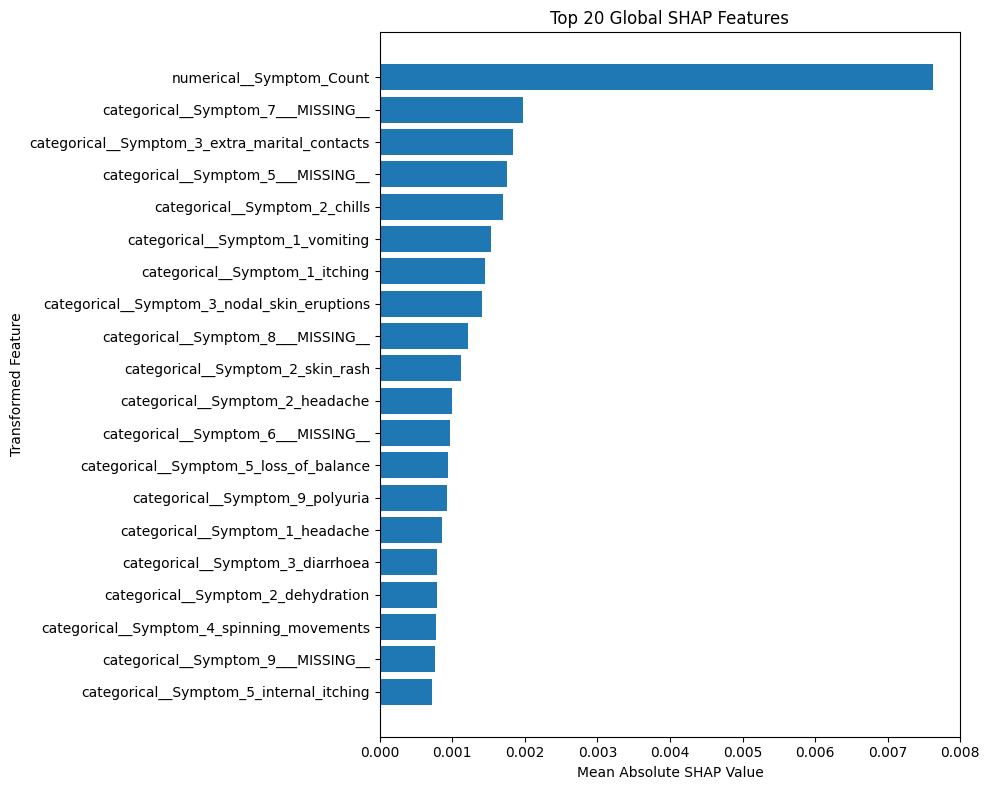

In [18]:
top_global = (
    global_importance_df
    .head(20)
    .sort_values(
        "Mean_Absolute_SHAP"
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_global["Feature"],
    top_global["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Transformed Feature"
)

plt.title(
    "Top 20 Global SHAP Features"
)

plt.tight_layout()

plt.show()

# 19. SHAP Summary Plot

The SHAP summary plot shows the distribution of feature contributions
for a representative disease class.

Each point represents a feature contribution for an individual
sample.

Features are ordered according to their overall importance.

SHAP SUMMARY CLASS
Selected class index: 31
Selected disease    : Osteoarthristis


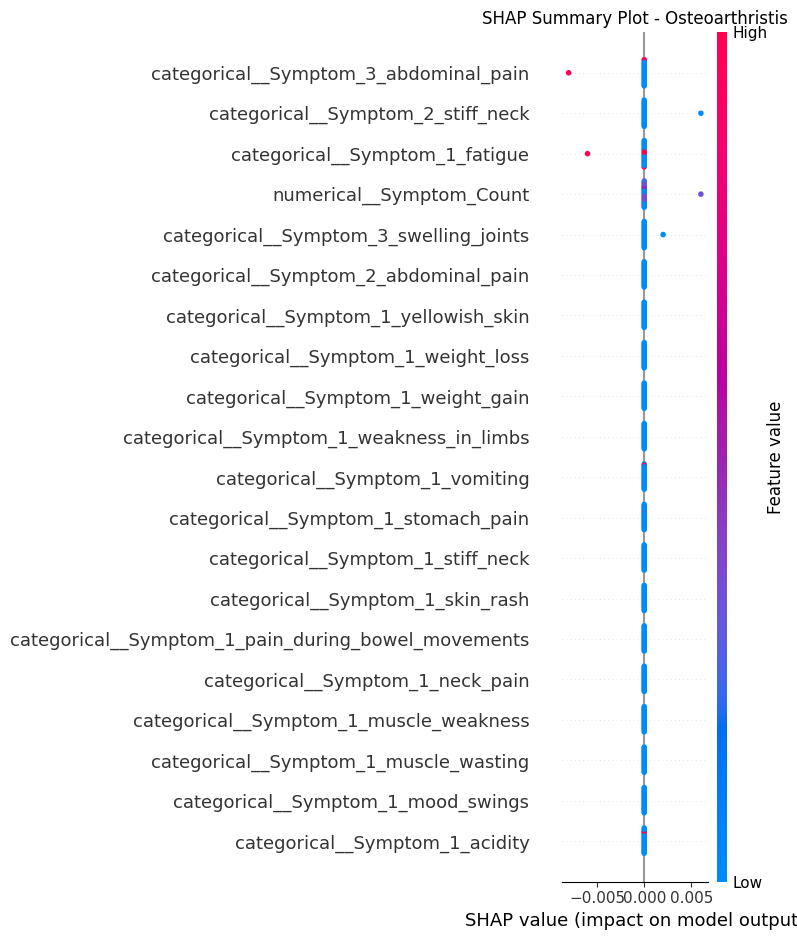

In [19]:
# Determine the most frequently predicted class
test_probabilities = pipeline.predict_proba(
    X_test_shap
)

test_predictions = pipeline.predict(
    X_test_shap
)

class_names = np.asarray(
    model.classes_
)

predicted_class_indices = np.argmax(
    test_probabilities,
    axis=1
)

summary_class_idx = (
    pd.Series(
        predicted_class_indices
    )
    .value_counts()
    .index[0]
)

summary_class_name = (
    class_names[
        summary_class_idx
    ]
)

print("=" * 60)
print("SHAP SUMMARY CLASS")
print("=" * 60)

print(
    f"Selected class index: "
    f"{summary_class_idx}"
)

print(
    f"Selected disease    : "
    f"{summary_class_name}"
)

plt.figure(
    figsize=(10, 8)
)

shap.summary_plot(
    shap_array[
        :,
        :,
        summary_class_idx
    ],
    X_explain_transformed,
    feature_names=feature_names,
    show=False
)

plt.title(
    f"SHAP Summary Plot - {summary_class_name}"
)

plt.tight_layout()

plt.show()

# 20. SHAP Bar Plot

A SHAP bar plot is generated for the selected representative disease
class.

The plot ranks features according to their average absolute SHAP
contribution.

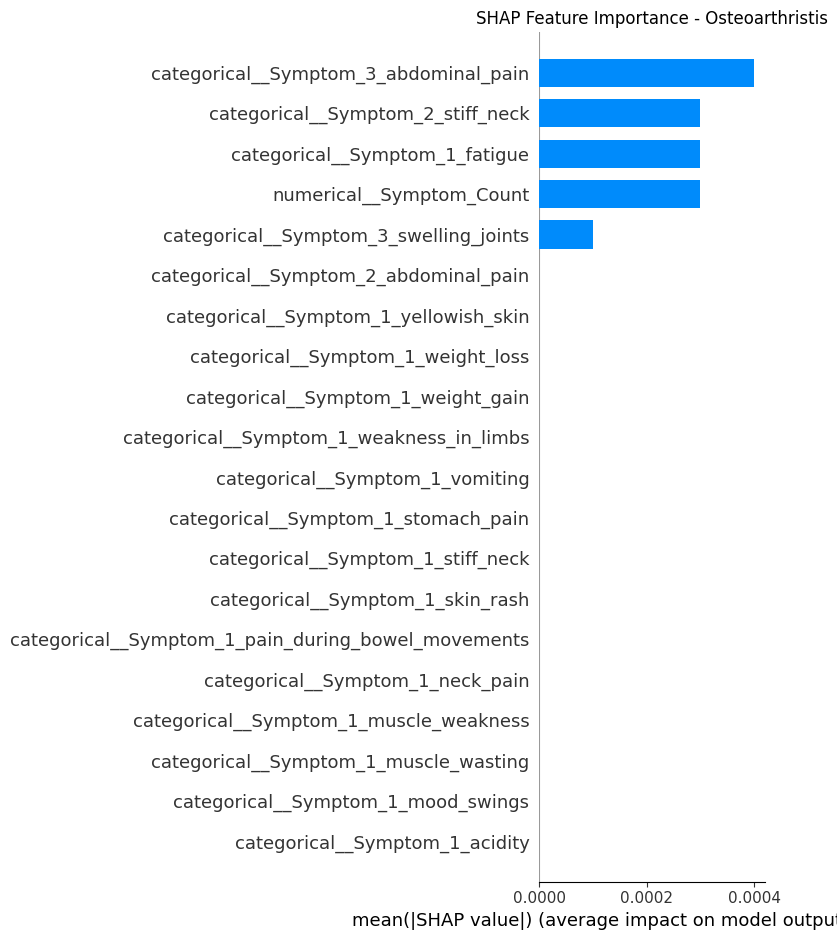

In [20]:
plt.figure(
    figsize=(10, 8)
)

shap.summary_plot(
    shap_array[
        :,
        :,
        summary_class_idx
    ],
    X_explain_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    f"SHAP Feature Importance - {summary_class_name}"
)

plt.tight_layout()

plt.show()

# 21. Individual Prediction Explanation

A single held-out test sample is selected for local explanation.

The analysis identifies:

- Actual disease
- Predicted disease
- Prediction confidence
- Top predicted disease probabilities

This provides the context for the individual SHAP explanation.

In [21]:
SAMPLE_INDEX = 0

sample_original = (
    X_test.iloc[SAMPLE_INDEX]
)

sample_actual = (
    y_test.iloc[SAMPLE_INDEX]
)

sample_probabilities = (
    pipeline.predict_proba(
        X_test_shap.iloc[
            [SAMPLE_INDEX]
        ]
    )[0]
)

sample_prediction = (
    pipeline.predict(
        X_test_shap.iloc[
            [SAMPLE_INDEX]
        ]
    )[0]
)

sample_predicted_class_idx = (
    int(
        np.argmax(
            sample_probabilities
        )
    )
)

sample_confidence = (
    float(
        sample_probabilities[
            sample_predicted_class_idx
        ]
    )
)

print("=" * 60)
print("INDIVIDUAL PREDICTION")
print("=" * 60)

print(f"Sample index    : {SAMPLE_INDEX}")
print(f"Actual disease  : {sample_actual}")
print(f"Predicted disease: {sample_prediction}")
print(
    f"Confidence      : "
    f"{sample_confidence:.2%}"
)

print("\n✓ Individual prediction prepared.")

INDIVIDUAL PREDICTION
Sample index    : 0
Actual disease  : Fungal infection
Predicted disease: Fungal infection
Confidence      : 100.00%

✓ Individual prediction prepared.


# 22. Local SHAP Waterfall Plot

The local SHAP waterfall plot explains the selected prediction.

The plot shows how individual transformed features move the model
output away from its baseline toward the prediction for the selected
disease class.

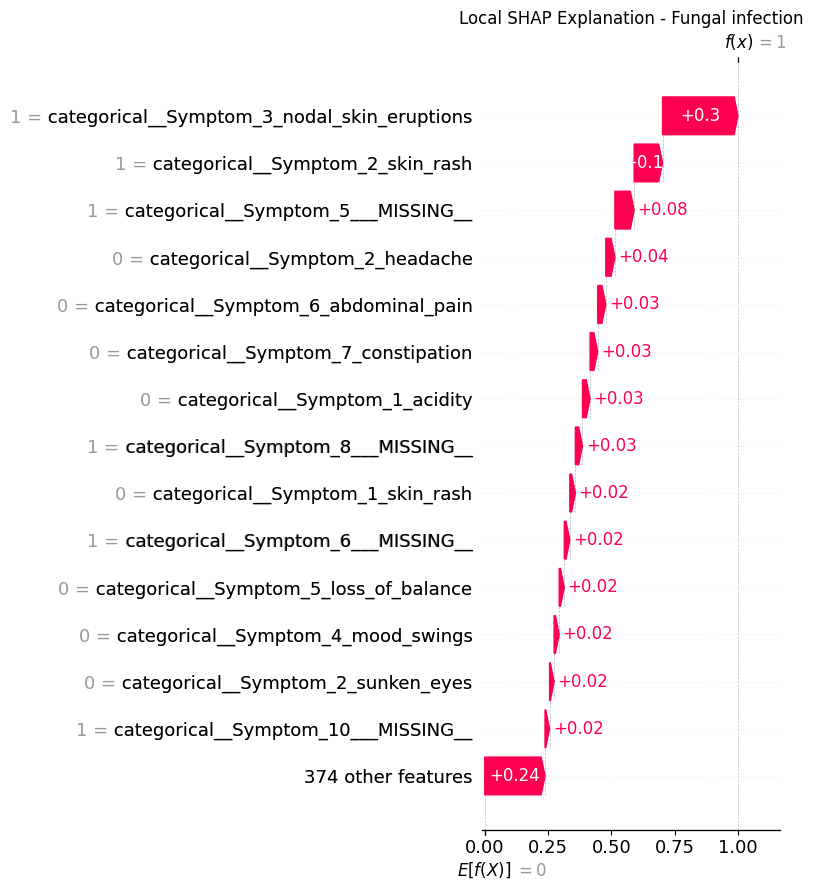

In [22]:
local_shap_values = (
    shap_array[
        SAMPLE_INDEX,
        :,
        sample_predicted_class_idx
    ]
)

base_values = np.asarray(
    shap_values.base_values
)

if base_values.ndim == 1:

    local_base_value = float(
        base_values[SAMPLE_INDEX]
    )

else:

    local_base_value = float(
        base_values[
            SAMPLE_INDEX,
            sample_predicted_class_idx
        ]
    )

local_explanation = shap.Explanation(
    values=local_shap_values,
    base_values=local_base_value,
    data=X_explain_transformed[
        SAMPLE_INDEX
    ],
    feature_names=feature_names
)

shap.plots.waterfall(
    local_explanation,
    max_display=15,
    show=False
)

plt.title(
    f"Local SHAP Explanation - "
    f"{sample_prediction}"
)

plt.tight_layout()

plt.show()

# 23. Connect Transformed Features to Original Symptoms

One-hot encoding creates multiple transformed features from each
original symptom column.

For human-readable interpretation, transformed SHAP features are
mapped back to their original source features.

For example:

`categorical__Symptom_1_abdominal_pain`

is mapped to:

`Symptom_1`

This allows SHAP contributions to be summarized at the original
symptom-feature level.

In [23]:
def map_to_original_feature(
    transformed_name
):
    if "__" in transformed_name:
        original_name = (
            transformed_name.split(
                "__",
                1
            )[1]
        )
    else:
        original_name = transformed_name

    for column in categorical_features:

        if (
            original_name == column
            or original_name.startswith(
                column + "_"
            )
        ):
            return column

    if original_name.startswith(
        "Symptom_Count"
    ):
        return "Symptom_Count"

    return original_name


original_feature_mapping = pd.DataFrame({
    "Transformed_Feature": feature_names,
    "Original_Feature": [
        map_to_original_feature(
            feature
        )
        for feature in feature_names
    ]
})

print("=" * 60)
print("TRANSFORMED → ORIGINAL FEATURE MAPPING")
print("=" * 60)

display(
    original_feature_mapping.head(30)
)

print("\n✓ Feature mapping created successfully.")

TRANSFORMED → ORIGINAL FEATURE MAPPING


,Transformed_Feature,Original_Feature
0,categorical__Symptom_1_acidity,Symptom_1
1,categorical__Symptom_1_back_pain,Symptom_1
2,categorical__Symptom_1_bladder_discomfort,Symptom_1
3,categorical__Symptom_1_breathlessness,Symptom_1
4,categorical__Symptom_1_burning_micturition,Symptom_1
5,categorical__Symptom_1_chest_pain,Symptom_1
6,categorical__Symptom_1_chills,Symptom_1
7,categorical__Symptom_1_constipation,Symptom_1
8,categorical__Symptom_1_continuous_sneezing,Symptom_1
9,categorical__Symptom_1_cough,Symptom_1



✓ Feature mapping created successfully.


# 24. Actual vs Predicted Disease

The final trained pipeline is used to generate predictions for the
complete held-out test set.

Actual and predicted disease labels are compared to provide a direct
view of the model's classification performance.

This is the same held-out test partition used during Week 3.

In [24]:
test_probabilities = (
    pipeline.predict_proba(
        X_test_shap
    )
)

test_predictions = (
    pipeline.predict(
        X_test_shap
    )
)

actual_vs_predicted = pd.DataFrame({
    "Actual_Disease": y_test.values,
    "Predicted_Disease": test_predictions,
    "Confidence": test_probabilities.max(
        axis=1
    )
})

actual_vs_predicted[
    "Correct"
] = (
    actual_vs_predicted[
        "Actual_Disease"
    ]
    ==
    actual_vs_predicted[
        "Predicted_Disease"
    ]
)

print("=" * 60)
print("ACTUAL VS PREDICTED")
print("=" * 60)

print(
    f"Test samples: "
    f"{len(actual_vs_predicted)}"
)

print(
    f"Correct predictions: "
    f"{actual_vs_predicted['Correct'].sum()}"
)

print(
    f"Incorrect predictions: "
    f"{(~actual_vs_predicted['Correct']).sum()}"
)

display(
    actual_vs_predicted.head(20)
)

print("\n✓ Actual vs predicted analysis completed.")

ACTUAL VS PREDICTED
Test samples: 996
Correct predictions: 996
Incorrect predictions: 0


,Actual_Disease,Predicted_Disease,Confidence,Correct
0,Fungal infection,Fungal infection,1.0,True
1,Fungal infection,Fungal infection,1.0,True
2,Allergy,Allergy,1.0,True
3,Allergy,Allergy,1.0,True
4,GERD,GERD,1.0,True
5,GERD,GERD,1.0,True
6,Chronic cholestasis,Chronic cholestasis,1.0,True
7,Drug Reaction,Drug Reaction,1.0,True
8,Peptic ulcer diseae,Peptic ulcer diseae,1.0,True
9,Peptic ulcer diseae,Peptic ulcer diseae,1.0,True



✓ Actual vs predicted analysis completed.


# 25. Top Positive and Negative SHAP Contributions

The local SHAP values for the selected prediction are analyzed to
identify the strongest positive and negative contributors.

Positive contributions push the model toward the predicted disease.

Negative contributions push the model away from the predicted disease.

The transformed features are also mapped to their original symptom
features for easier interpretation.

In [25]:
local_contributions = pd.DataFrame({
    "Transformed_Feature": feature_names,
    "SHAP_Value": local_shap_values
})

local_contributions[
    "Original_Feature"
] = (
    local_contributions[
        "Transformed_Feature"
    ]
    .map(
        dict(
            zip(
                original_feature_mapping[
                    "Transformed_Feature"
                ],
                original_feature_mapping[
                    "Original_Feature"
                ]
            )
        )
    )
)

positive_contributions = (
    local_contributions
    .sort_values(
        "SHAP_Value",
        ascending=False
    )
    .head(10)
)

negative_contributions = (
    local_contributions
    .sort_values(
        "SHAP_Value",
        ascending=True
    )
    .head(10)
)

print("=" * 60)
print("TOP POSITIVE CONTRIBUTIONS")
print("=" * 60)

display(
    positive_contributions
)

print("=" * 60)
print("TOP NEGATIVE CONTRIBUTIONS")
print("=" * 60)

display(
    negative_contributions
)

TOP POSITIVE CONTRIBUTIONS


,Transformed_Feature,SHAP_Value,Original_Feature
113,categorical__Symptom_3_nodal_skin_eruptions,0.298,Symptom_3
65,categorical__Symptom_2_skin_rash,0.112,Symptom_2
183,categorical__Symptom_5___MISSING__,0.076,Symptom_5
47,categorical__Symptom_2_headache,0.036,Symptom_2
221,categorical__Symptom_6_abdominal_pain,0.032,Symptom_6
256,categorical__Symptom_7_constipation,0.030,Symptom_7
0,categorical__Symptom_1_acidity,0.030,Symptom_1
277,categorical__Symptom_8___MISSING__,0.028,Symptom_8
22,categorical__Symptom_1_skin_rash,0.022,Symptom_1
220,categorical__Symptom_6___MISSING__,0.022,Symptom_6


TOP NEGATIVE CONTRIBUTIONS


,Transformed_Feature,SHAP_Value,Original_Feature
384,categorical__Symptom_16_muscle_pain,0.0,Symptom_16
369,categorical__Symptom_13_muscle_pain,0.0,Symptom_13
370,categorical__Symptom_13_phlegm,0.0,Symptom_13
371,categorical__Symptom_13_red_spots_over_body,0.0,Symptom_13
372,categorical__Symptom_13_runny_nose,0.0,Symptom_13
373,categorical__Symptom_13_stomach_bleeding,0.0,Symptom_13
374,categorical__Symptom_14___MISSING__,0.0,Symptom_14
375,categorical__Symptom_14_chest_pain,0.0,Symptom_14
376,categorical__Symptom_14_congestion,0.0,Symptom_14
377,categorical__Symptom_14_red_spots_over_body,0.0,Symptom_14


In [26]:
original_local_contributions = (
    local_contributions
    .groupby(
        "Original_Feature",
        as_index=False
    )["SHAP_Value"]
    .sum()
    .sort_values(
        "SHAP_Value",
        ascending=False
    )
)

print("=" * 60)
print("ORIGINAL FEATURE CONTRIBUTIONS")
print("=" * 60)

display(
    original_local_contributions
)

ORIGINAL FEATURE CONTRIBUTIONS


,Original_Feature,SHAP_Value
10,Symptom_3,0.356
9,Symptom_2,0.212
12,Symptom_5,0.110
0,Symptom_1,0.072
11,Symptom_4,0.068
13,Symptom_6,0.058
14,Symptom_7,0.038
15,Symptom_8,0.038
1,Symptom_10,0.018
16,Symptom_9,0.010


# 26. Save SHAP Results

The SHAP analysis results are saved as CSV files.

The saved outputs include:

- Global feature importance
- Local SHAP contributions
- Original-feature contributions
- Transformed-to-original feature mapping
- Actual vs predicted results
- Individual explanation metadata

These files can be reused for project documentation, research
analysis, and future application development.

In [27]:
global_importance_path = (
    SHAP_OUTPUT_DIR
    / "global_shap_importance.csv"
)

local_contributions_path = (
    SHAP_OUTPUT_DIR
    / "local_shap_contributions.csv"
)

original_contributions_path = (
    SHAP_OUTPUT_DIR
    / "original_feature_contributions.csv"
)

feature_mapping_path = (
    SHAP_OUTPUT_DIR
    / "feature_mapping.csv"
)

predictions_path = (
    SHAP_OUTPUT_DIR
    / "actual_vs_predicted.csv"
)

metadata_path = (
    SHAP_OUTPUT_DIR
    / "explanation_metadata.csv"
)

global_importance_df.to_csv(
    global_importance_path,
    index=False
)

local_contributions.to_csv(
    local_contributions_path,
    index=False
)

original_local_contributions.to_csv(
    original_contributions_path,
    index=False
)

original_feature_mapping.to_csv(
    feature_mapping_path,
    index=False
)

actual_vs_predicted.to_csv(
    predictions_path,
    index=False
)

explanation_metadata = pd.DataFrame({
    "Property": [
        "Selected model",
        "SHAP explainer",
        "Explanation samples",
        "Background samples",
        "Transformed feature count",
        "Predicted disease",
        "Actual disease",
        "Prediction confidence"
    ],
    "Value": [
        type(model).__name__,
        explainer_type,
        len(X_explain_transformed),
        len(background_data),
        len(feature_names),
        sample_prediction,
        sample_actual,
        sample_confidence
    ]
})

explanation_metadata.to_csv(
    metadata_path,
    index=False
)

print("=" * 60)
print("SHAP RESULTS SAVED")
print("=" * 60)

print(
    f"✓ {global_importance_path.name}"
)

print(
    f"✓ {local_contributions_path.name}"
)

print(
    f"✓ {original_contributions_path.name}"
)

print(
    f"✓ {feature_mapping_path.name}"
)

print(
    f"✓ {predictions_path.name}"
)

print(
    f"✓ {metadata_path.name}"
)

print("\n✓ SHAP analysis results saved successfully.")

SHAP RESULTS SAVED
✓ global_shap_importance.csv
✓ local_shap_contributions.csv
✓ original_feature_contributions.csv
✓ feature_mapping.csv
✓ actual_vs_predicted.csv
✓ explanation_metadata.csv

✓ SHAP analysis results saved successfully.


# 27. Save SHAP Visualizations

The main SHAP visualizations are saved as high-resolution PNG files.

These figures can be used in:

- Project documentation
- Research paper
- Presentation
- README
- Explainable AI analysis

In [28]:
global_plot_path = (
    SHAP_OUTPUT_DIR
    / "global_shap_importance.png"
)

summary_plot_path = (
    SHAP_OUTPUT_DIR
    / "shap_summary_plot.png"
)

bar_plot_path = (
    SHAP_OUTPUT_DIR
    / "shap_bar_plot.png"
)

waterfall_plot_path = (
    SHAP_OUTPUT_DIR
    / "shap_waterfall_plot.png"
)

# Global importance plot

plt.figure(
    figsize=(10, 8)
)

top_global = (
    global_importance_df
    .head(20)
    .sort_values(
        "Mean_Absolute_SHAP"
    )
)

plt.barh(
    top_global["Feature"],
    top_global["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 Global SHAP Features"
)

plt.tight_layout()

plt.savefig(
    global_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Summary plot

plt.figure(
    figsize=(10, 8)
)

shap.summary_plot(
    shap_array[
        :,
        :,
        summary_class_idx
    ],
    X_explain_transformed,
    feature_names=feature_names,
    show=False
)

plt.title(
    f"SHAP Summary - "
    f"{summary_class_name}"
)

plt.tight_layout()

plt.savefig(
    summary_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Bar plot

plt.figure(
    figsize=(10, 8)
)

shap.summary_plot(
    shap_array[
        :,
        :,
        summary_class_idx
    ],
    X_explain_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    f"SHAP Feature Importance - "
    f"{summary_class_name}"
)

plt.tight_layout()

plt.savefig(
    bar_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Waterfall plot

shap.plots.waterfall(
    local_explanation,
    max_display=15,
    show=False
)

plt.title(
    f"Local SHAP Explanation - "
    f"{sample_prediction}"
)

plt.tight_layout()

plt.savefig(
    waterfall_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("=" * 60)
print("SHAP VISUALIZATIONS SAVED")
print("=" * 60)

for path in [
    global_plot_path,
    summary_plot_path,
    bar_plot_path,
    waterfall_plot_path
]:
    print(f"✓ {path.name}")

print("\n✓ SHAP visualizations saved successfully.")

SHAP VISUALIZATIONS SAVED
✓ global_shap_importance.png
✓ shap_summary_plot.png
✓ shap_bar_plot.png
✓ shap_waterfall_plot.png

✓ SHAP visualizations saved successfully.


# 28. Confidence Threshold Logic

A real-world disease prediction system should not present every
prediction as equally reliable.

A confidence threshold of 60% is introduced.

If the highest predicted probability is below 60%, the system marks
the prediction as uncertain and recommends consultation with a
qualified healthcare professional.

This threshold is a project-level safety rule and does not represent
a medically validated diagnostic threshold.

In [29]:
CONFIDENCE_THRESHOLD = 0.60


def evaluate_prediction_confidence(
    probabilities,
    class_names,
    threshold=CONFIDENCE_THRESHOLD
):

    probabilities = np.asarray(
        probabilities
    )

    top_index = int(
        np.argmax(probabilities)
    )

    top_confidence = float(
        probabilities[top_index]
    )

    top_disease = (
        class_names[top_index]
    )

    is_confident = (
        top_confidence >= threshold
    )

    return {
        "disease": top_disease,
        "confidence": top_confidence,
        "is_confident": is_confident,
        "threshold": threshold
    }


sample_confidence_result = (
    evaluate_prediction_confidence(
        sample_probabilities,
        class_names
    )
)

print("=" * 60)
print("CONFIDENCE THRESHOLD")
print("=" * 60)

print(
    f"Threshold : "
    f"{CONFIDENCE_THRESHOLD:.0%}"
)

print(
    f"Prediction: "
    f"{sample_confidence_result['disease']}"
)

print(
    f"Confidence: "
    f"{sample_confidence_result['confidence']:.2%}"
)

print(
    f"Confident : "
    f"{sample_confidence_result['is_confident']}"
)

CONFIDENCE THRESHOLD
Threshold : 60%
Prediction: Fungal infection
Confidence: 100.00%
Confident : True


# 29. Top-3 Differential Diagnosis

The system does not return only one possible disease.

Instead, the three highest-probability disease classes are returned
with their predicted probabilities.

This provides a differential-diagnosis style output and reflects the
fact that symptom patterns can overlap across multiple diseases.

The results are model predictions and should not be interpreted as a
clinical diagnosis.

In [30]:
def get_top_3_predictions(
    probabilities,
    class_names
):

    probabilities = np.asarray(
        probabilities
    )

    top_indices = (
        np.argsort(
            probabilities
        )[::-1][:3]
    )

    results = []

    for rank, index in enumerate(
        top_indices,
        start=1
    ):

        results.append({
            "Rank": rank,
            "Disease": class_names[index],
            "Probability": float(
                probabilities[index]
            )
        })

    return pd.DataFrame(
        results
    )


top_3_predictions = (
    get_top_3_predictions(
        sample_probabilities,
        class_names
    )
)

print("=" * 60)
print("TOP-3 DIFFERENTIAL PREDICTION")
print("=" * 60)

display(
    top_3_predictions
)

print("\n✓ Top-3 prediction logic completed.")

TOP-3 DIFFERENTIAL PREDICTION


,Rank,Disease,Probability
0,1,Fungal infection,1.0
1,2,Varicose veins,0.0
2,3,Urinary tract infection,0.0



✓ Top-3 prediction logic completed.


In [31]:
if (
    sample_confidence
    < CONFIDENCE_THRESHOLD
):

    print(
        "\n⚠ Prediction confidence is below "
        f"{CONFIDENCE_THRESHOLD:.0%}."
    )

    print(
        "The prediction should be treated as uncertain."
    )

else:

    print(
        f"\n✓ Top prediction exceeds the "
        f"{CONFIDENCE_THRESHOLD:.0%} project threshold."
    )


✓ Top prediction exceeds the 60% project threshold.


# 30. Medical Disclaimer

The prediction system is designed for educational and research
purposes.

It is not a substitute for professional medical diagnosis,
consultation, or treatment.

Every user-facing prediction should contain an appropriate medical
disclaimer.

In [32]:
MEDICAL_DISCLAIMER = (
    "For educational and informational purposes only. "
    "This system does not provide a medical diagnosis. "
    "The predictions are generated by a machine learning model "
    "and should not be used as a substitute for professional "
    "medical advice, diagnosis, or treatment. "
    "Please consult a qualified healthcare professional "
    "for medical concerns."
)

print("=" * 60)
print("MEDICAL DISCLAIMER")
print("=" * 60)

print(MEDICAL_DISCLAIMER)

print("\n✓ Medical disclaimer defined successfully.")

MEDICAL DISCLAIMER
For educational and informational purposes only. This system does not provide a medical diagnosis. The predictions are generated by a machine learning model and should not be used as a substitute for professional medical advice, diagnosis, or treatment. Please consult a qualified healthcare professional for medical concerns.

✓ Medical disclaimer defined successfully.


# 31. Final Week 4 Validation

The final validation checks whether the complete SHAP explainability
workflow has produced the required outputs.

The validation includes:

- Trained model availability
- SHAP results
- Global feature importance
- Local contributions
- Feature mapping
- Prediction results
- SHAP visualizations
- Confidence threshold
- Top-3 prediction logic
- Medical disclaimer

All required outputs should exist before Week 4 is considered
complete.

In [33]:
required_shap_outputs = {
    "Global SHAP importance": global_importance_path,
    "Local SHAP contributions": local_contributions_path,
    "Original feature contributions": original_contributions_path,
    "Feature mapping": feature_mapping_path,
    "Actual vs predicted": predictions_path,
    "Explanation metadata": metadata_path,
    "Global SHAP plot": global_plot_path,
    "SHAP summary plot": summary_plot_path,
    "SHAP bar plot": bar_plot_path,
    "SHAP waterfall plot": waterfall_plot_path
}

validation_results = []

print("=" * 60)
print("FINAL WEEK 4 VALIDATION")
print("=" * 60)

for output_name, output_path in (
    required_shap_outputs.items()
):

    exists = output_path.exists()

    validation_results.append({
        "Output": output_name,
        "Exists": exists,
        "Path": str(output_path)
    })

    status = "✓" if exists else "✗"

    print(
        f"{status} {output_name}"
    )

validation_df = pd.DataFrame(
    validation_results
)

print("\n")
display(validation_df)

assert validation_df[
    "Exists"
].all(), (
    "One or more SHAP outputs are missing."
)

assert (
    CONFIDENCE_THRESHOLD == 0.60
)

assert (
    len(top_3_predictions) == 3
)

assert isinstance(
    MEDICAL_DISCLAIMER,
    str
)

assert (
    len(MEDICAL_DISCLAIMER) > 0
)

print("\n✓ All required SHAP outputs exist.")
print("✓ Confidence threshold validated.")
print("✓ Top-3 prediction logic validated.")
print("✓ Medical disclaimer validated.")
print("\n✓ WEEK 4 VALIDATION PASSED SUCCESSFULLY.")

FINAL WEEK 4 VALIDATION
✓ Global SHAP importance
✓ Local SHAP contributions
✓ Original feature contributions
✓ Feature mapping
✓ Actual vs predicted
✓ Explanation metadata
✓ Global SHAP plot
✓ SHAP summary plot
✓ SHAP bar plot
✓ SHAP waterfall plot




,Output,Exists,Path
0,Global SHAP importance,True,..\data\processed\shap_outputs\global_shap_imp...
1,Local SHAP contributions,True,..\data\processed\shap_outputs\local_shap_cont...
2,Original feature contributions,True,..\data\processed\shap_outputs\original_featur...
3,Feature mapping,True,..\data\processed\shap_outputs\feature_mapping...
4,Actual vs predicted,True,..\data\processed\shap_outputs\actual_vs_predi...
5,Explanation metadata,True,..\data\processed\shap_outputs\explanation_met...
6,Global SHAP plot,True,..\data\processed\shap_outputs\global_shap_imp...
7,SHAP summary plot,True,..\data\processed\shap_outputs\shap_summary_pl...
8,SHAP bar plot,True,..\data\processed\shap_outputs\shap_bar_plot.png
9,SHAP waterfall plot,True,..\data\processed\shap_outputs\shap_waterfall_...



✓ All required SHAP outputs exist.
✓ Confidence threshold validated.
✓ Top-3 prediction logic validated.
✓ Medical disclaimer validated.

✓ WEEK 4 VALIDATION PASSED SUCCESSFULLY.


# 32. Conclusion

The SHAP explainability stage of the AI Disease Prediction System has
been completed.

The final trained machine learning pipeline from Week 3 was reused
without retraining.

SHAP was used to analyze:

- Global feature importance
- Feature-level contributions
- Individual predictions
- Positive and negative feature contributions
- Original symptom-level influence

The explainability workflow provides a way to answer:

> "Why did the model make this prediction?"

The notebook also introduces real-world prediction logic:

- A 60% confidence threshold
- Top-3 differential predictions
- Uncertainty handling
- A medical disclaimer for user-facing responses

The generated SHAP results and visualizations are saved for use in
the research paper, project documentation, presentation, and future
application development.

## Week 4 Outputs

The SHAP analysis generates:

- `global_shap_importance.csv`
- `local_shap_contributions.csv`
- `original_feature_contributions.csv`
- `feature_mapping.csv`
- `actual_vs_predicted.csv`
- `explanation_metadata.csv`
- `global_shap_importance.png`
- `shap_summary_plot.png`
- `shap_bar_plot.png`
- `shap_waterfall_plot.png`

## Next Stage

The next development stage can integrate the trained model,
explainability logic, confidence handling, and differential prediction
logic into the application's backend API.